Once I correctly match a post-promo day to a normal day of the same weekday, does that post-promo day sell noticeably less than normal?

If yes → evidence of shifting (demand got pulled forward into the promo, leaving a dip after)
If no, roughly the same → evidence against shifting, more consistent with the promo just being genuinely additional sales, not borrowed from late

I'm checking if the day right after a promo ends sells less than a normal day like it. If it does, that means people probably bought stuff early because of the promo instead of buying more overall. If it doesn't, that means the promo actually brought in new sales, not just moved them around.

In [288]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [289]:
store = pd.read_csv('store.csv')
train = pd.read_csv('train.csv', dtype={'StateHoliday': str})

In [290]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [291]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5   Open           1017209 non-null  int64
 6   Promo          1017209 non-null  int64
 7   StateHoliday   1017209 non-null  str  
 8   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(2)
memory usage: 69.8 MB


In [292]:
#Filtering out for only open stores so 0 sales doesn't interfere
train_open = train[train['Open'] == 1]
train_open.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Store          844392 non-null  int64
 1   DayOfWeek      844392 non-null  int64
 2   Date           844392 non-null  str  
 3   Sales          844392 non-null  int64
 4   Customers      844392 non-null  int64
 5   Open           844392 non-null  int64
 6   Promo          844392 non-null  int64
 7   StateHoliday   844392 non-null  str  
 8   SchoolHoliday  844392 non-null  int64
dtypes: int64(7), str(2)
memory usage: 64.4 MB


Filtering out closed stores first since 0 sales on closed days would mess with comparing promo vs non promo sales

In [293]:
train_open['Promo'].value_counts() ### See how many stores have promos

Promo
0    467496
1    376896
Name: count, dtype: int64

Checking how many open days had a promo running vs not, want to make sure its a decent split and not some tiny edge case

In [294]:
train_open.groupby("Promo")["Sales"].mean()

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64

So this information tells us in retrospect that sure promo stores make more sales. However, we must count for confounders. 

In [295]:
dayWeekPromo= train_open.groupby(['DayOfWeek', 'Promo'])['Sales'].mean()

Rossmann does not run promos on weekends, so this analysis can only speak to the promo effect on weekdays (days 1–5). We have no data to evaluate weekend promo effectiveness.

In [296]:
train_open.head(5000) ###checking how the stores are oganized by date

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
5004,545,1,2015-07-27,15617,1138,1,1,0,1
5005,546,1,2015-07-27,14939,1666,1,1,0,1
5006,547,1,2015-07-27,9027,577,1,1,0,0
5007,548,1,2015-07-27,7215,466,1,1,0,1


In [297]:
train_sorted = train_open.sort_values(by=(['Store','Date']), ascending=True)
train_sorted

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1014980,1,3,2013-01-02,5530,668,1,0,0,1
1013865,1,4,2013-01-03,4327,578,1,0,0,1
1012750,1,5,2013-01-04,4486,619,1,0,0,1
1011635,1,6,2013-01-05,4997,635,1,0,0,1
1009405,1,1,2013-01-07,7176,785,1,1,0,1
...,...,...,...,...,...,...,...,...,...
5574,1115,1,2015-07-27,10712,608,1,1,0,1
4459,1115,2,2015-07-28,8093,500,1,1,0,1
3344,1115,3,2015-07-29,7661,473,1,1,0,1
2229,1115,4,2015-07-30,8405,502,1,1,0,1


Sorting by store then date so each store's rows are in actual chronological order, need this before I can check what happens day to day

In [298]:
train_sorted['PromoNextDay'] = train_sorted.groupby('Store')['Promo'].shift(-1)
###this will never affect multiple stores 

train_sorted["SalesNextDay"] =train_sorted.groupby("Store")['Sales'].shift(-1)
train_sorted["DayOfWeekNext"] = train_sorted.groupby("Store")['DayOfWeek'].shift(-1)

train_sorted['DateNext'] = train_sorted.groupby("Store")["Date"].shift(-1)

train_sorted[['Store', 'Date', 'Promo', 'PromoNextDay', 'SalesNextDay', 'DayOfWeekNext', 'DateNext']].head(100)


,Store,Date,Promo,PromoNextDay,SalesNextDay,DayOfWeekNext,DateNext
1014980,1,2013-01-02,0,0.0,4327.0,4.0,2013-01-03
1013865,1,2013-01-03,0,0.0,4486.0,5.0,2013-01-04
1012750,1,2013-01-04,0,0.0,4997.0,6.0,2013-01-05
1011635,1,2013-01-05,0,1.0,7176.0,1.0,2013-01-07
1009405,1,2013-01-07,1,1.0,5580.0,2.0,2013-01-08
...,...,...,...,...,...,...,...
888985,1,2013-04-25,1,1.0,4841.0,5.0,2013-04-26
887870,1,2013-04-26,1,0.0,5726.0,6.0,2013-04-27
886755,1,2013-04-27,0,1.0,5821.0,1.0,2013-04-29
884525,1,2013-04-29,1,1.0,5925.0,2.0,2013-04-30


Using shift to grab tomorrows promo status for each store, grouped by store so I don't accidentally pull in another store's data at the boundary

So what this did was check what stores have a promo the next day and which don't. This will help us compare the sales of a promo week to a non promo week to see if there was an effect. 

In [299]:
train_sorted['DateNext'] = pd.to_datetime(train_sorted['DateNext'])
train_sorted['Date'] = pd.to_datetime(train_sorted['Date'])
#converting these to dates that pandas can read

train_sorted['DayGap'] = (train_sorted['DateNext'] - train_sorted['Date']).dt.days

train_sorted[['Store', 'Date', 'Promo', 'PromoNextDay', 'SalesNextDay', 'DayOfWeekNext', 'DateNext','DayGap']].head(100)




,Store,Date,Promo,PromoNextDay,SalesNextDay,DayOfWeekNext,DateNext,DayGap
1014980,1,2013-01-02,0,0.0,4327.0,4.0,2013-01-03,1.0
1013865,1,2013-01-03,0,0.0,4486.0,5.0,2013-01-04,1.0
1012750,1,2013-01-04,0,0.0,4997.0,6.0,2013-01-05,1.0
1011635,1,2013-01-05,0,1.0,7176.0,1.0,2013-01-07,2.0
1009405,1,2013-01-07,1,1.0,5580.0,2.0,2013-01-08,1.0
...,...,...,...,...,...,...,...,...
888985,1,2013-04-25,1,1.0,4841.0,5.0,2013-04-26,1.0
887870,1,2013-04-26,1,0.0,5726.0,6.0,2013-04-27,1.0
886755,1,2013-04-27,0,1.0,5821.0,1.0,2013-04-29,2.0
884525,1,2013-04-29,1,1.0,5925.0,2.0,2013-04-30,1.0


In [300]:
train_sorted['PromoLastDay'] = (train_sorted['Promo']==1) & (train_sorted["PromoNextDay"] == 0)
cleanPostPromo = train_sorted[(train_sorted['PromoLastDay'] == True) & (train_sorted['DayGap'] == 1)]
cleanPostPromo


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,PromoNextDay,SalesNextDay,DayOfWeekNext,DateNext,DayGap,PromoLastDay
1004945,1,5,2013-01-11,4881,592,1,1,0,1,0.0,4952.0,6.0,2013-01-12,1.0,True
989335,1,5,2013-01-25,5586,676,1,1,0,0,0.0,5598.0,6.0,2013-01-26,1.0,True
973725,1,5,2013-02-08,5681,630,1,1,0,0,0.0,5370.0,6.0,2013-02-09,1.0,True
958115,1,5,2013-02-22,5000,599,1,1,0,0,0.0,5237.0,6.0,2013-02-23,1.0,True
942505,1,5,2013-03-08,5853,694,1,1,0,0,0.0,5578.0,6.0,2013-03-09,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79164,1115,5,2015-05-22,8449,547,1,1,0,0,0.0,8005.0,6.0,2015-05-23,1.0,True
63554,1115,5,2015-06-05,11435,653,1,1,0,0,0.0,6596.0,6.0,2015-06-06,1.0,True
47944,1115,5,2015-06-19,8291,535,1,1,0,0,0.0,7824.0,6.0,2015-06-20,1.0,True
32334,1115,5,2015-07-03,7412,478,1,1,0,0,0.0,6543.0,6.0,2015-07-04,1.0,True


Checking whether a promo is on that day ==1 and whether the nextday is 0 to confirm that its the last day for the promo that week.

In [301]:
train_sorted['SalesNextDay'] = train_sorted.groupby('Store')['Sales'].shift(-1)
train_sorted['SalesNext2Day'] = train_sorted.groupby('Store')['Sales'].shift(-2)
train_sorted['SalesNext3Day'] = train_sorted.groupby('Store')['Sales'].shift(-3)
# getting the sales of the 3 days after a promo ends



In [302]:
postPromoMeans_fixed = cleanPostPromo.groupby('DayOfWeekNext')[['SalesNextDay']].mean()
postPromoMeans_fixed
cleanPostPromo.groupby('DayOfWeekNext')[['SalesNextDay']].count()

,SalesNextDay
DayOfWeekNext,
6.0,71031


In [303]:
dayWeekPromo = dayWeekPromo.unstack()
#Unstack() method so each unique value becomes its own coloumn
dayWeekPromo = dayWeekPromo.rename(columns={0: 'No Promo', 1: 'Promo'})
#rename for clarity

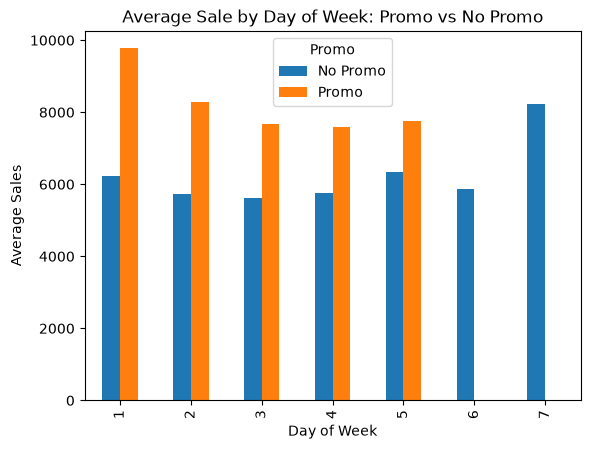

In [304]:
dayWeekPromo.plot(kind = 'bar')
plt.title("Average Sale by Day of Week: Promo vs No Promo")
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.show()

In [309]:
fri_to_sat = train_sorted[(train_sorted['DayOfWeekNext'] == 6) & (train_sorted['DayGap'] == 1)]

sat_after_promo_fri = fri_to_sat[fri_to_sat['Promo'] == 1]
sat_after_normal_fri = fri_to_sat[fri_to_sat['Promo'] == 0]

sat_after_promo_fri['SalesNextDay'].mean(), sat_after_normal_fri['SalesNextDay'].mean()



(np.float64(5806.21033070068), np.float64(5776.447065766774))

In [312]:
dif = 5806.21-5776.45
percent = dif/5776.45
percent*100

0.5151953189242566

In [306]:
sat_after_promo_fri['SalesNextDay'].count(), sat_after_normal_fri['SalesNextDay'].count()

(np.int64(71031), np.int64(66082))

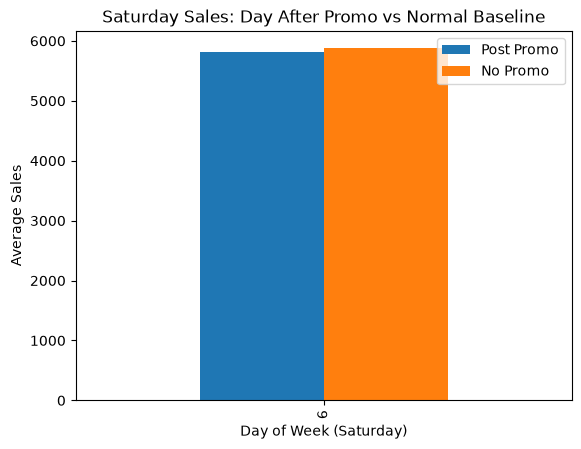

In [307]:
satCompDF.plot(kind='bar')
plt.title('Saturday Sales: Day After Promo vs Normal Baseline')
plt.xlabel('Day of Week (Saturday)')
plt.ylabel('Average Sales')
plt.show()

I had to separate the Saturdays following a promo Friday vs Saturdays following a non-promo Friday because the non-promo Friday group was including the post-promo Saturdays. After separating these correctly, post-promo Saturdays averaged 5806.21 vs 5776.45 for normal Saturdays, a gap of about $30 (+0.5%), with large samples on both sides (71,031 vs 66,082). This is a small gap, suggesting little to no evidence that Friday promos are creating a next day dip, which I didn't expect originally. I haven't formally tested whether this small gap is statistically meaningful or just random variation, and observations from the same store across different weeks aren't fully independent, so I'm treating this as a preliminary finding rather than a definitive one.